In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
df = pd.read_csv("adult.csv")

print("First 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nShape:")
print(df.shape)

First 5 Rows:
   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356              18 

In [5]:
df.replace(" ?", np.nan, inplace=True)
df.replace("?", np.nan, inplace=True)

In [6]:
null_count = df.isnull().sum()
print(null_count)

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [7]:
null_percent = (df.isnull().sum()/len(df))*100
print(null_percent)

age               0.000000
workclass         5.638647
fnlwgt            0.000000
education         0.000000
education.num     0.000000
marital.status    0.000000
occupation        5.660146
relationship      0.000000
race              0.000000
sex               0.000000
capital.gain      0.000000
capital.loss      0.000000
hours.per.week    0.000000
native.country    1.790486
income            0.000000
dtype: float64


In [8]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [9]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
duplicates=df.duplicated().sum()

print("Duplicate Rows:",duplicates)

Duplicate Rows: 24


In [11]:
before=df.shape[0]

df=df.drop_duplicates()

after=df.shape[0]

print("Rows Removed:",before-after)

Rows Removed: 24


In [12]:
print((df.isnull().sum()/len(df))*100)

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education.num     0.0
marital.status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital.gain      0.0
capital.loss      0.0
hours.per.week    0.0
native.country    0.0
income            0.0
dtype: float64


In [13]:
print(df.dtypes)

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object


In [14]:
cat_cols=[
'workclass',
'education',
'marital.status',
'occupation',
'relationship',
'race',
'sex',
'native.country',
'income'
]

for col in cat_cols:
    df[col]=df[col].astype("category")

In [15]:
print(df.memory_usage(deep=True).sum())

2124955


In [16]:
print(df.memory_usage(deep=True).sum())

2124955


In [17]:
print(df.describe())

                age        fnlwgt  education.num  capital.gain  capital.loss  \
count  32537.000000  3.253700e+04   32537.000000  32537.000000  32537.000000   
mean      38.585549  1.897808e+05      10.081815   1078.443741     87.368227   
std       13.637984  1.055565e+05       2.571633   7387.957424    403.101833   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.369930e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours.per.week  
count    32537.000000  
mean        40.440329  
std         12.346889  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


In [18]:
skew=df.skew(numeric_only=True)

print(skew)

age                0.557663
fnlwgt             1.447703
education.num     -0.309500
capital.gain      11.949403
capital.loss       4.592702
hours.per.week     0.228759
dtype: float64


In [19]:
highest_skew=skew.abs().idxmax()

print(highest_skew)

capital.gain


In [20]:
Q1=df["age"].quantile(.25)

Q3=df["age"].quantile(.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

outliers=df[(df["age"]<lower)|(df["age"]>upper)]

print(len(outliers))

142


In [21]:
Q1=df["hours.per.week"].quantile(.25)

Q3=df["hours.per.week"].quantile(.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

outliers=df[(df["hours.per.week"]<lower)|(df["hours.per.week"]>upper)]

print(len(outliers))

9002


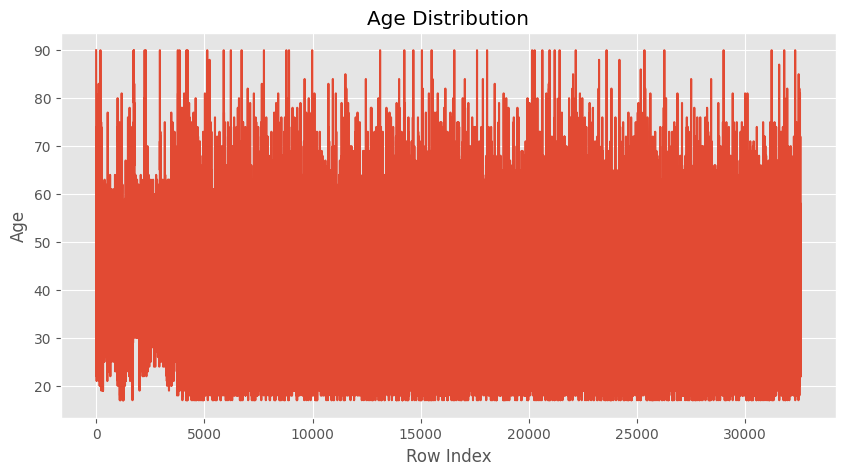

In [22]:
plt.figure(figsize=(10,5))

plt.plot(df["age"])

plt.title("Age Distribution")

plt.xlabel("Row Index")

plt.ylabel("Age")

plt.show()

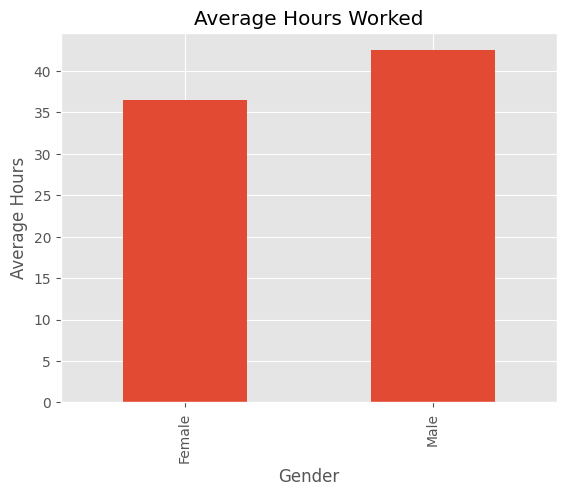

In [23]:
df.groupby("sex",observed=False)["hours.per.week"].mean().plot.bar()

plt.title("Average Hours Worked")

plt.xlabel("Gender")

plt.ylabel("Average Hours")

plt.show()

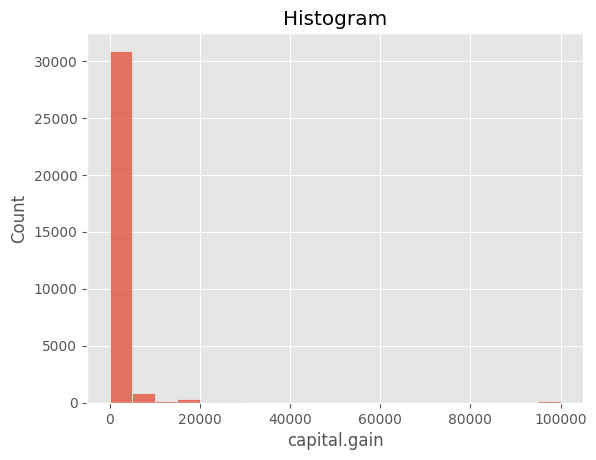

In [24]:
sns.histplot(df[highest_skew],bins=20)

plt.title("Histogram")

plt.show()

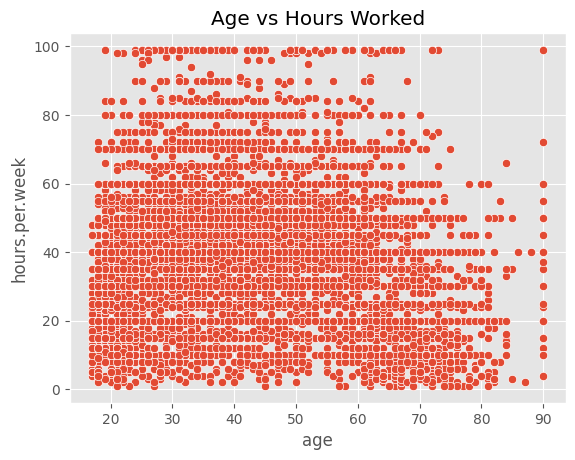

In [25]:
sns.scatterplot(x="age",y="hours.per.week",data=df)

plt.title("Age vs Hours Worked")

plt.show()

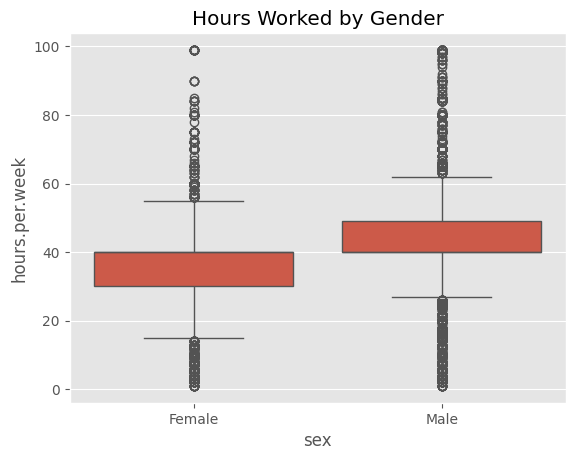

In [26]:
sns.boxplot(x="sex",y="hours.per.week",data=df)

plt.title("Hours Worked by Gender")

plt.show()

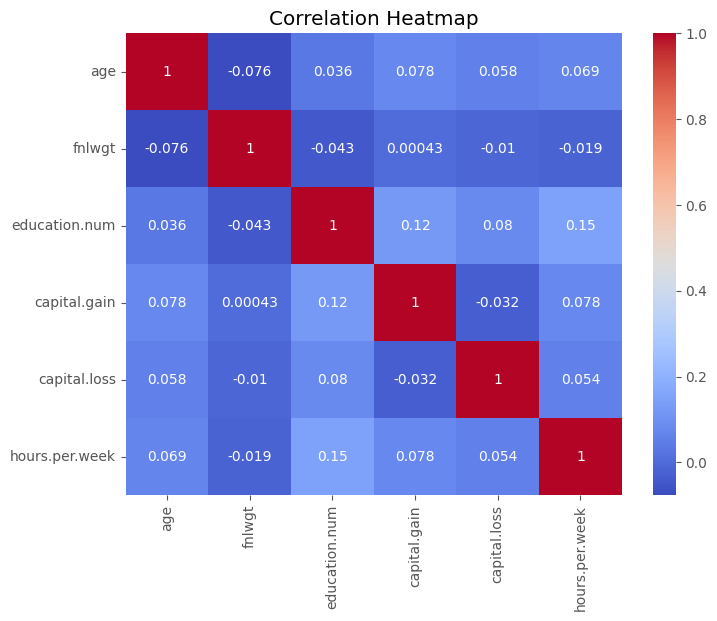

In [27]:
corr=df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [28]:
corr_abs=corr.abs()

np.fill_diagonal(corr_abs.values,0)

print(corr_abs.unstack().sort_values(ascending=False))

hours.per.week  education.num     0.148422
education.num   hours.per.week    0.148422
                capital.gain      0.122664
capital.gain    education.num     0.122664
education.num   capital.loss      0.079892
capital.loss    education.num     0.079892
capital.gain    hours.per.week    0.078408
hours.per.week  capital.gain      0.078408
capital.gain    age               0.077676
age             capital.gain      0.077676
                fnlwgt            0.076447
fnlwgt          age               0.076447
hours.per.week  age               0.068515
age             hours.per.week    0.068515
                capital.loss      0.057745
capital.loss    age               0.057745
                hours.per.week    0.054229
hours.per.week  capital.loss      0.054229
fnlwgt          education.num     0.043388
education.num   fnlwgt            0.043388
                age               0.036224
age             education.num     0.036224
capital.gain    capital.loss      0.031639
capital.los

In [29]:
top2=skew.abs().sort_values(ascending=False).head(2).index

for col in top2:
    print(col)
    print("Mean:",df[col].mean())
    print("Median:",df[col].median())

capital.gain
Mean: 1078.4437409718166
Median: 0.0
capital.loss
Mean: 87.36822694163568
Median: 0.0


In [30]:
top2=['capital.gain','capital.loss']
for col in top2:
   df[col]= df[col].fillna(df[col].median())

print(df[top2].isnull().sum())

capital.gain    0
capital.loss    0
dtype: int64


In [31]:
pearson=df.corr(numeric_only=True)

spearman=df.corr(method="spearman",numeric_only=True)

print(pearson)

print(spearman)

                     age    fnlwgt  education.num  capital.gain  capital.loss  \
age             1.000000 -0.076447       0.036224      0.077676      0.057745   
fnlwgt         -0.076447  1.000000      -0.043388      0.000429     -0.010260   
education.num   0.036224 -0.043388       1.000000      0.122664      0.079892   
capital.gain    0.077676  0.000429       0.122664      1.000000     -0.031639   
capital.loss    0.057745 -0.010260       0.079892     -0.031639      1.000000   
hours.per.week  0.068515 -0.018898       0.148422      0.078408      0.054229   

                hours.per.week  
age                   0.068515  
fnlwgt               -0.018898  
education.num         0.148422  
capital.gain          0.078408  
capital.loss          0.054229  
hours.per.week        1.000000  
                     age    fnlwgt  education.num  capital.gain  capital.loss  \
age             1.000000 -0.077917       0.066199      0.124905      0.058433   
fnlwgt         -0.077917  1.000000     

In [32]:
difference=(spearman-pearson).abs()

print(difference)

                     age    fnlwgt  education.num  capital.gain  capital.loss  \
age             0.000000  0.001469       0.029975      0.047229      0.000688   
fnlwgt          0.001469  0.000000       0.007560      0.006460      0.003350   
education.num   0.029975  0.007560       0.000000      0.003538      0.005162   
capital.gain    0.047229  0.006460       0.003538      0.000000      0.034983   
capital.loss    0.000688  0.003350       0.005162      0.034983      0.000000   
hours.per.week  0.074248  0.002984       0.019043      0.014908      0.005613   

                hours.per.week  
age                   0.074248  
fnlwgt                0.002984  
education.num         0.019043  
capital.gain          0.014908  
capital.loss          0.005613  
hours.per.week        0.000000  


In [35]:
result=df.groupby("sex",observed=False)["hours.per.week"].agg(["mean","std","count"])

print(result)

             mean        std  count
sex                                
Female  36.415257  11.807462  10762
Male    42.429667  12.121336  21775


In [36]:
print(result["mean"].idxmax())

Male


In [37]:
print(result["std"].idxmax())

Male


In [38]:
ratio=result["mean"].max()/result["mean"].min()

print(ratio)

1.1651618056226043


In [40]:
df.to_csv("cleaned_data.csv",index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully
